# Exploratory Data Analysis and Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# import warnings
# warnings.filterwarnings('ignore') # if jupyter is giving some annoying warnings

# for plotting
sns.set_style('whitegrid')
# plt.rcParams['figure.figsize'] = (12, 6) # make plots a bit bigger

print('libs loaded')

libs loaded


## Load Training Data

In [2]:
TRAIN_PATH = 'train.csv'
df_train = pd.read_csv(TRAIN_PATH)
print("Dataset Shape:", df_train.shape)
print("\nColumns:")
print(df_train.columns)

Dataset Shape: (75000, 4)

Columns:
Index(['sample_id', 'catalog_content', 'image_link', 'price'], dtype='object')


In [3]:
print("First 5 samples:")
df_train.head()

First 5 samples:


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [4]:
print("Dataset Info:")
df_train.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB


## Missing Value Analysis

Check for any missing or null values across all columns.

In [5]:
# check for missing data
missing_vals = df_train.isnull().sum()
missing_percentage = (missing_vals / len(df_train) * 100).round(2)

missing_df = pd.DataFrame({'count': missing_vals, 'percentage': missing_percentage})
missing_df = missing_df[missing_df['count'] > 0].sort_values('count', ascending=False)

if not missing_df.empty:
    print("Missing values summary:")
    print(missing_df)
else:
    print("No missing values found.")

# also need to check for empty strings in 'catalog_content'
empty_catalog = (df_train['catalog_content'].str.strip() == '').sum()
print(f"\nEmpty 'catalog_content' entries: {empty_catalog}")

No missing values found.

Empty 'catalog_content' entries: 0


## Price Distribution Analysis

Analyze the target variable (price) to understand its distribution and characteristics.

In [6]:
# lets see the distribution of price
print('Price stats:')
print(df_train.price.describe())
print('skew:', df_train.price.skew())
print('kurtosis:', df_train.price.kurtosis())

Price stats:
count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
25%          6.795000
50%         14.000000
75%         28.625000
max       2796.000000
Name: price, dtype: float64
skew: 13.601388975432753
kurtosis: 736.6545083222634


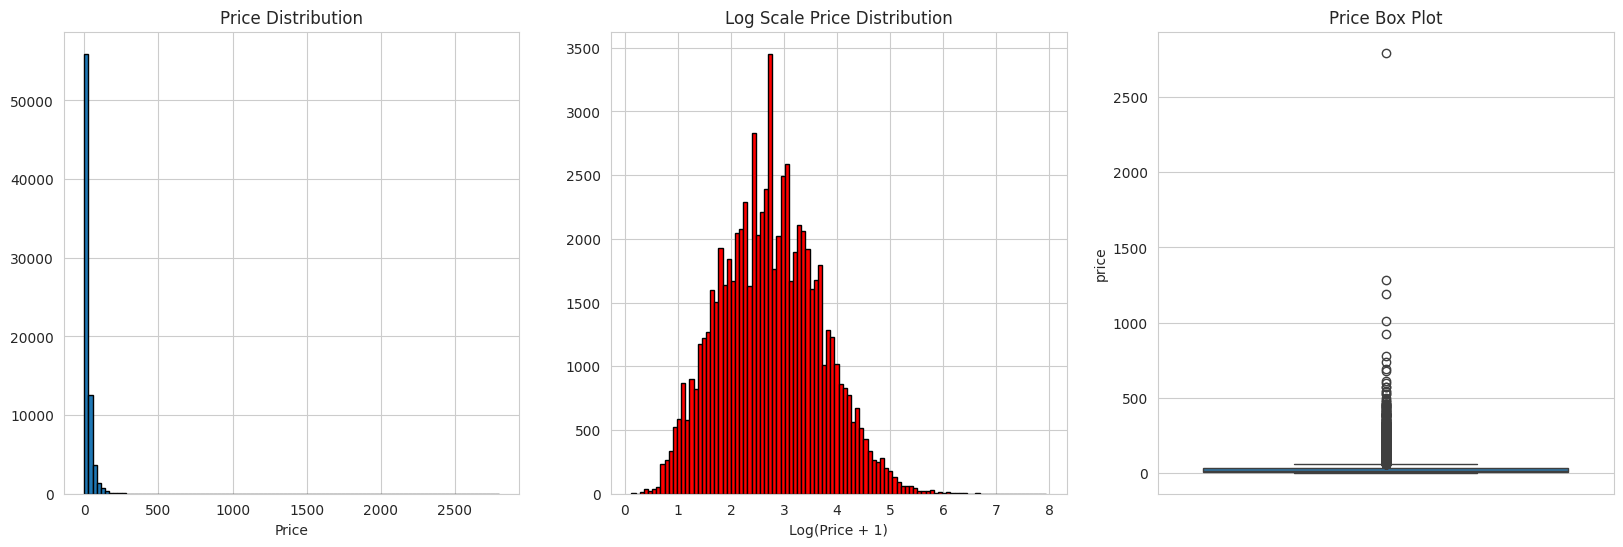

In [7]:
# how does price look?
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# a simple histogram
df_train['price'].hist(ax=ax1, bins=100, edgecolor='black')
ax1.set_title('Price Distribution')
ax1.set_xlabel('Price')

np.log1p(df_train['price']).hist(ax=ax2, bins=100, edgecolor='black', color='red')
ax2.set_title('Log Scale Price Distribution')
ax2.set_xlabel('Log(Price + 1)')

# box plot for outliers
sns.boxplot(y=df_train['price'], ax=ax3)
ax3.set_title('Price Box Plot')

plt.show()

## Outlier Detection

Identify extreme price values that might need special handling.

In [8]:
# calculate outliers using IQR
q1 = df_train['price'].quantile(0.25)
q3 = df_train['price'].quantile(0.75)
iqr = q3-q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
print(f'IQR Outlier thresholds: < {lower_bound:.2f} and > {upper_bound:.2f}')
outliers = df_train[(df_train['price'] < lower_bound) | (df_train['price'] > upper_bound)]
print(f'Num of outliers: {len(outliers)}')
print(f'Percent of data that is outlier: {len(outliers)/len(df_train)*100:.2f}%')
print("\nTop 10 most expensive products:")
df_train.nlargest(10, 'price')[['sample_id', 'price', 'catalog_content']]

IQR Outlier thresholds: < -25.95 and > 61.37
Num of outliers: 5524
Percent of data that is outlier: 7.37%

Top 10 most expensive products:


,sample_id,price,catalog_content
58617,229126,2796.00,Item Name: 4Patriots 1-Year Survival Food Kit:...
32153,134909,1280.00,Item Name: Royal Amber Osetra Caviar - Russian...
22839,62251,1188.00,Item Name: 495 days proteins meal 33 bottles x...
46301,195806,1010.54,Item Name: China Beauty Rings Tea (Loose) (8 o...
68388,236048,921.50,"Item Name: Organic Pistachios Shelled Raw, 30 ..."
72853,262694,779.25,Item Name: Numanna Family Pack Bucket 432 Serv...
73067,190026,739.99,"Item Name: Crystal Geyser Pallet Of 84 Cases, ..."
45580,272914,691.16,"Item Name: Topps Juicy Drop Pop, 18 count per ..."
56075,227791,679.92,Item Name: Alex's Low Acid Organic Coffee Ulti...
4146,46413,613.58,Item Name: Beverage/Topping Heated Condiment D...


## Catalog Content Analysis

Examine the textual content to understand product descriptions.

In [9]:
# create some features from the text
df_train['text_length'] = df_train['catalog_content'].str.len()
df_train['word_count'] = df_train['catalog_content'].apply(lambda x: len(str(x).split()))

print("Text Stats:")
print(df_train[['text_length', 'word_count']].describe())
print("\nSome random examples:")
print("-" * 25)
for _, row in df_train.sample(3).iterrows():
    print(f"Price: {row['price']:.2f}")
    print(f"Content Snippet: {row['catalog_content'][:200]}...")
    print("-" * 25)

Text Stats:
        text_length    word_count
count  75000.000000  75000.000000
mean     908.886547    147.851693
std      852.896151    137.068731
min       32.000000      7.000000
25%      251.000000     42.000000
50%      643.000000    104.000000
75%     1280.000000    208.000000
max     7894.000000   1333.000000

Some random examples:
-------------------------
Price: 12.50
Content Snippet: Item Name: Arrowhead Mills Spelt Flakes Organic Cereal, 12 Ounce Box
Bullet Point 1: Contains 1 - 6 ounce box of cereal
Bullet Point 2: Certified Organic, Non GMO Project Verified
Bullet Point 3: 100%...
-------------------------
Price: 13.99
Content Snippet: Item Name: FirstChoiceCandy Sweet & Sour Gummy Worms, Multi Flavors and Solid Colors (2 Pound, Sour Red Strawberry)
Bullet Point 1: Delicious Flavor: Indulge in the sweet and tangy taste of these gumm...
-------------------------
Price: 43.08
Content Snippet: Item Name: Finest Call Premium Strawberry Puree Drink Mix, 1 Liter Bottle (33.8 Fl 

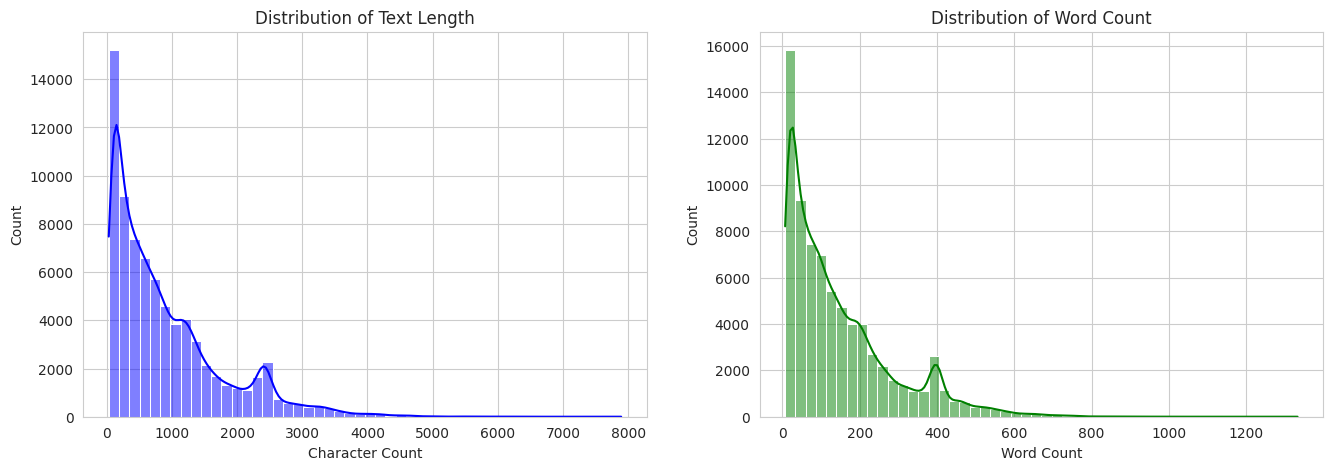

In [10]:
# plotting text length and word count distributions

plt.figure(figsize=(16, 5))

# subplot 1 for text length
plt.subplot(1, 2, 1)
sns.histplot(df_train['text_length'], bins=50, color='blue', kde=True)
plt.title('Distribution of Text Length')
plt.xlabel('Character Count')

# subplot 2 for word count
plt.subplot(1, 2, 2)
sns.histplot(df_train['word_count'], bins=50, color='green', kde=True)
plt.title('Distribution of Word Count')
plt.xlabel('Word Count')

plt.show()

## Extract Key Information from Catalog Content

Try to identify patterns like pack quantity, brand mentions, product categories.

In [11]:
# Try to get pack size from the text, like "pack of 6" etc.
# important feature for price

def find_pack_size(text):
    if pd.isna(text):
        return 1

    text = text.lower()

    # Pattern 1: pack of X
    match = re.search(r'pack of (\d+)', text)
    if match:
        return int(match.group(1))

    # Pattern 2: X pack
    match = re.search(r'(\d+)\s*pack', text)
    if match:
        return int(match.group(1))

    # Pattern 3: X pieces, X count...
    match = re.search(r'(\d+)\s*(piece|count|set)', text)
    if match:
        return int(match.group(1))

    return 1 # if we dont find anything, assume its 1

df_train['pack_quantity'] = df_train['catalog_content'].apply(find_pack_size)
print("Pack Quantity Counts:")
print(df_train['pack_quantity'].value_counts().nlargest(10))
print(f"\nNumber of items with pack size > 1: {(df_train['pack_quantity'] > 1).sum()}")

Pack Quantity Counts:
pack_quantity
1     45948
6      5272
12     4960
2      4329
3      3718
4      2283
24     1356
8      1168
10      733
5       517
Name: count, dtype: int64

Number of items with pack size > 1: 29037


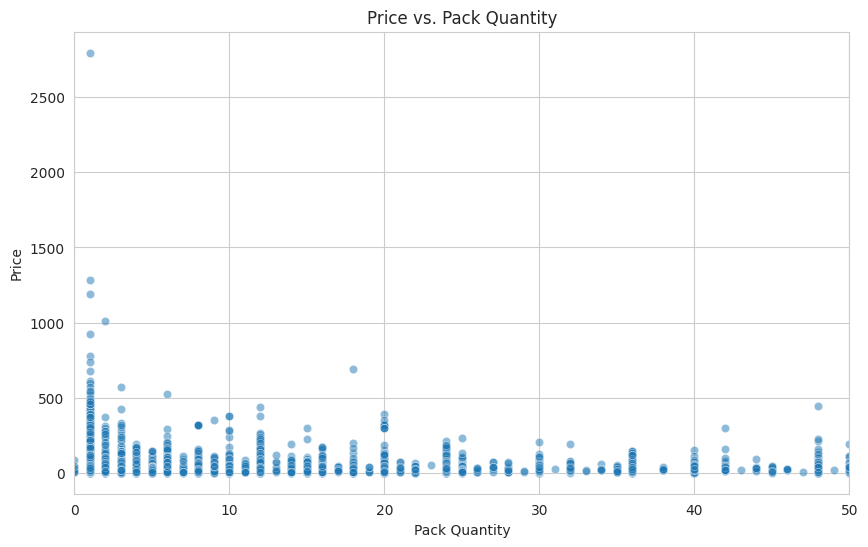


Correlation is: 0.010005150530979405


In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pack_quantity', y='price', data=df_train, alpha=0.5)
plt.title('Price vs. Pack Quantity')
plt.xlabel('Pack Quantity')
plt.ylabel('Price')
plt.xlim(0, 50)
plt.show()
corr = df_train['pack_quantity'].corr(df_train['price'])
print(f"\nCorrelation is: {corr}")

## Common Words and Patterns

Identify frequently occurring terms that might be useful features.

In [13]:
from collections import Counter
import string

def find_common_words(text_data, num_words=20):
    full_text = ' '.join(text_data.dropna()).lower()

    # remove punctuation
    full_text = full_text.translate(str.maketrans('', '', string.punctuation))
    words = full_text.split()

    # a simple list of words to ignore
    stopwords = ['the', 'and', 'for', 'with', 'from', 'this', 'that', 'are', 'was', 'has', 'new']
    good_words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(good_words).most_common(num_words)


# top 30
top_words = find_common_words(df_train['catalog_content'], num_words=30)

print("Most Common Words:")
print(top_words)

Most Common Words:
[('point', 267970), ('bullet', 267690), ('our', 82449), ('your', 80532), ('value', 78846), ('item', 77835), ('name', 76446), ('unit', 75594), ('tea', 69297), ('you', 58965), ('ounce', 58395), ('flavor', 54616), ('product', 44026), ('coffee', 42148), ('pack', 41723), ('taste', 38497), ('free', 37831), ('natural', 35144), ('organic', 33987), ('description', 32962), ('perfect', 32683), ('made', 31469), ('ingredients', 31159), ('all', 29164), ('delicious', 28433), ('water', 28192), ('candy', 25957), ('sugar', 25695), ('chocolate', 25564), ('can', 24988)]


## Image Link Analysis

Check image link availability and patterns.

In [14]:
print("Image Link Info:")
print(f"Total: {len(df_train)}")
print(f"With links: {df_train['image_link'].notna().sum()}")
print(f"Missing: {df_train['image_link'].isna().sum()}")
print(f"Unique links: {df_train['image_link'].nunique()}")
img_counts = df_train['image_link'].value_counts()
shared_imgs = img_counts[img_counts > 1]
print(f"\nNumber of images shared by multiple products: {len(shared_imgs)}")
print(f"An image is shared at most {shared_imgs.max()} times.")

Image Link Info:
Total: 75000
With links: 75000
Missing: 0
Unique links: 72288

Number of images shared by multiple products: 2175
An image is shared at most 52 times.


## Price Statistics by Segments

Break down price statistics by different characteristics.

Count per price category:
price_bin
<20        47922
20-50      18986
50-100      6199
100-200     1595
>200         298
Name: count, dtype: int64


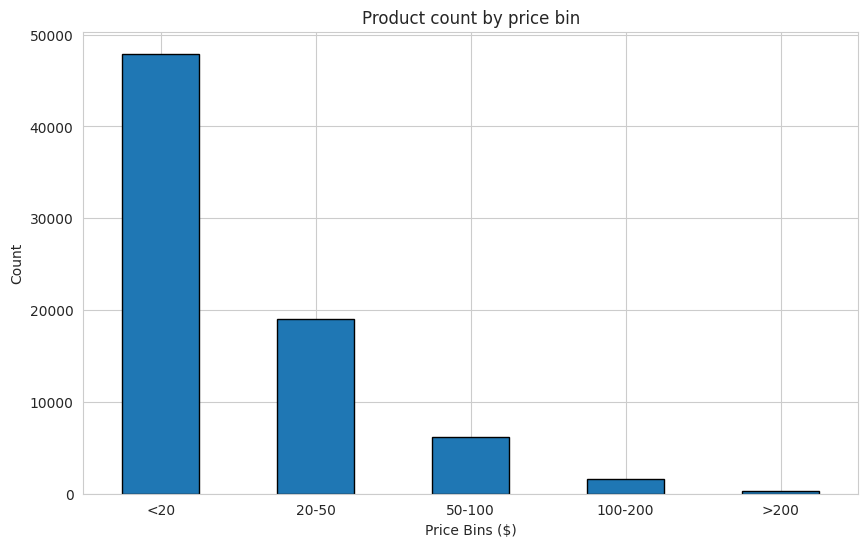

In [15]:
price_bins = [0, 20, 50, 100, 200, np.inf]
bin_labels = ['<20', '20-50', '50-100', '100-200', '>200']

df_train['price_bin'] = pd.cut(df_train['price'], bins=price_bins, labels=bin_labels)

print("Count per price category:")
print(df_train['price_bin'].value_counts().sort_index())

df_train['price_bin'].value_counts().sort_index().plot(kind='bar', figsize=(10, 6), edgecolor='k')
plt.title('Product count by price bin')
plt.ylabel('Count')
plt.xlabel('Price Bins ($)')
plt.xticks(rotation=0)
plt.show()

## Data Quality Report

Summary of data quality findings.

In [16]:
print("--- Summary ---")

print(f"\n1. Size: {len(df_train)} entries")

print("\n2. Missing Values:")
# only show columns that actually have missing values
missing_counts = df_train.isnull().sum()
print(missing_counts[missing_counts > 0])


print("\n3. Price Info:")
price_stats = df_train['price'].describe()
print(f"   Range: {price_stats['min']:.2f} - {price_stats['max']:.2f}")
print(f"   Mean: {price_stats['mean']:.2f}")


print("\n4. Text Info:")
print(f"   Avg text length: {df_train['text_length'].mean():.0f} characters")
print(f"   Avg word count: {df_train['word_count'].mean():.0f} words")


print("\n5. Outliers (based on IQR):")
print(f"   Number of price outliers: {len(outliers)}")

print("--------------------------")

--- Summary ---

1. Size: 75000 entries

2. Missing Values:
Series([], dtype: int64)

3. Price Info:
   Range: 0.13 - 2796.00
   Mean: 23.65

4. Text Info:
   Avg text length: 909 characters
   Avg word count: 148 words

5. Outliers (based on IQR):
   Number of price outliers: 5524
--------------------------


## Save Cleaned Data with Basic Features

Save processed data with extracted features for next stages.

In [17]:
cols_to_keep = [
    'sample_id',
    'catalog_content',
    'image_link',
    'price',
    'text_length',
    'word_count',
    'pack_quantity'
]

final_df = df_train[cols_to_keep].copy()
final_df.to_csv('train_cleaned.csv', index=False)
print('Saved final df to train_cleaned.csv')
print(f'Shape is: {final_df.shape}')

Saved final df to train_cleaned.csv
Shape is: (75000, 7)
